In [1]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df = df.drop(['deck', 'embark_town', 'alive'], axis=1, errors='ignore')

In [5]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
#Handle Missing Values
df['age'] = df['age'].fillna(df['age'].median())
#Embarked
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
#Convert Boolean → Intege
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [7]:
#Encode Categorical Columns
df = pd.get_dummies(df, columns=['sex', 'embarked', 'who'], drop_first=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   age         891 non-null    float64 
 3   sibsp       891 non-null    int64   
 4   parch       891 non-null    int64   
 5   fare        891 non-null    float64 
 6   class       891 non-null    category
 7   adult_male  891 non-null    int64   
 8   alone       891 non-null    int64   
 9   sex_male    891 non-null    bool    
 10  embarked_Q  891 non-null    bool    
 11  embarked_S  891 non-null    bool    
 12  who_man     891 non-null    bool    
 13  who_woman   891 non-null    bool    
dtypes: bool(5), category(1), float64(2), int64(6)
memory usage: 61.2 KB


In [18]:
X = df.drop(["survived"], axis=1)
y = df["survived"]

# train test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Drop problematic column
X_train = X_train.drop('class', axis=1)
X_test = X_test.drop('class', axis=1)

# Convert bool → int
bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# 1. Logistic Regression

In [21]:
lr = LogisticRegression()

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(lr, lr_params, cv=5)
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

# 2. Random Forest

In [22]:
rf = RandomForestClassifier()

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

# 3. XGBoost

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

# Evaluate Models

In [24]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }

In [25]:
#Evaluate All Models
lr_result = evaluate_model(best_lr, X_test, y_test)
rf_result = evaluate_model(best_rf, X_test, y_test)
xgb_result = evaluate_model(best_xgb, X_test, y_test)

In [26]:
#Comparison Table
results = pd.DataFrame({
    "Logistic Regression": lr_result,
    "Random Forest": rf_result,
    "XGBoost": xgb_result
}).T

print(results)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.815642   0.797101  0.743243  0.769231  0.804955
Random Forest        0.810056   0.803030  0.716216  0.757143  0.796203
XGBoost              0.826816   0.830769  0.729730  0.776978  0.812484


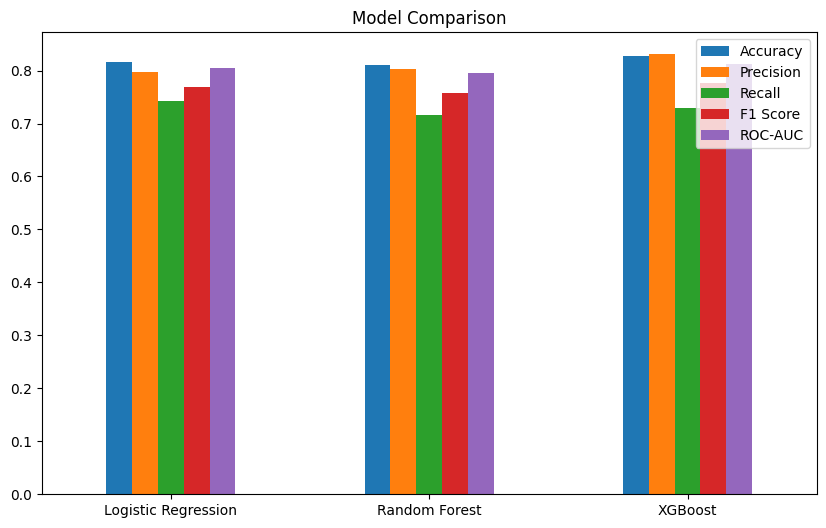

In [27]:
import matplotlib.pyplot as plt

results.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [28]:
best_model = results["F1 Score"].idxmax()
print("Best Model:", best_model)

Best Model: XGBoost
